# Methodology: from flyby physics to the optimum-interval limit

**Paper element.** Supplemental Material, The Transferred Momentum: figure
`02_spectra` (the differential rate of momentum transfers at the showcase point),
together with the halo, attenuation, cross-section and statistics chain written up
in that section and in Limit Setting.

**Private.** The pipeline behind
[`01_limit_contour.ipynb`](01_limit_contour.ipynb), one section per stage. Like
notebook 01 it is **mode-aware**: set `MODE_NUMBER` to pick the sensor mode
whose candidates mark the spectra figure and whose extremeness plane the
appendix spot-checks. That mode's efficiency (shown in
[`00_efficiency_and_blips.ipynb`](00_efficiency_and_blips.ipynb)) enters the
cube's limit surfaces, not the showcase curves drawn here: `/reference_curves`
stores the raw $dR/dq$, before $\varepsilon(q)$, so the two figures below are
the same for every mode.

1. **Halo**: SHM speed distribution at the top of the atmosphere (`luhdm.halo`).
2. **Attenuation**: every trajectory is slowed through the atmosphere by the
   energy-loss ODE (`luhdm.atmosphere`); the detector-frame $f(v)$ carries the
   survival fraction.
3. **Cross section**: classical $K_1$-impulse from a finite-range Yukawa on the
   finite-size magnet (`luhdm.cross_section`; a log-space variant keeps the
   shortest ranges finite where the direct Bessels degrade at large
   $\xi = R_\text{eff}/\lambda$).
4. **Rate**: $dR/dq = \varepsilon(q)\,n_\text{DM}\int f(v)\,v\,(d\sigma/dq)\,dv$,
   assembled by **`luhdm/rate.py`** — the single module imported by the notebooks
   *and* the cluster scripts (`scripts/scan_grid.py`, `scripts/scan_lambda.py`,
   `scripts/make_maps.py`), so the two can never drift. It carries the DM-fraction
   fiducial $f_X$ = `config.F_X` and folds in the per-mode detection efficiency
   $\varepsilon(q)$ shown in notebook 00.
5. **Statistics**: the optimum-interval extremeness (`luhdm.limits`, wrapping the
   public `optimum_interval` package), explained below.

Fiducials (threshold $q_\text{th}$ = 1 TeV/$c$, exposure $T$ = 219.66 h, $f_X$,
$R_\text{eff}$) live in `luhdm/config.py`; the physics that gets tweaked lives in
`luhdm/rate.py`. Change either and the notebooks re-execute unchanged.

Two conventions of the current release run through everything below. The
impact-parameter integral is **uncapped** — the only cutoff is the inner one at
$R_\text{eff}$ — so the excluded region is closed on the right not by the cross
section but by a separate halo flux cut $m_\text{cut}$, stored in the file's
`m_cut_*` attributes and assuming $N_\text{req} = 3$ transits within 10 cm
during the exposure. And the analysis window starts at 1 TeV/$c$, which puts a
hard kinematic wall at $q_\text{th}/v_\text{esc} = 5.51\times10^{5}$ GeV on the
left. Neither is visible in the spectra drawn here; both bound the limits of
[`01_limit_contour.ipynb`](01_limit_contour.ipynb).

The showcase curves and diagnostics in this notebook — the arrival-speed
distributions, the spectra, and the appendix spot-check table — are **read from
the data release** (`luhdm_datarelease_v9_A_f1_atm.h5`, the $f_\mathrm{DM}$ = 1
file with atmospheric attenuation — see the version tag in the file /
`release/README.md`), where they were computed
by this same `luhdm.rate` pipeline at build time; the notebook only loads and
plots them, so it can never drift from the cluster scans.

In [1]:
# ===== CONFIG: which sensor mode this notebook analyses =====
MODE_NUMBER = 1   # 1, 2, or 3

%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, units
from luhdm import release

# File A of the released pair: f_DM = 1 with atmospheric attenuation. It is
# also luhdm.release.DEFAULT_PATH, the --release default of the paper-figure
# scripts, so notebook and script read the same cube.
rel = release.open_release("../release/luhdm_datarelease_v9_A_f1_atm.h5")

R_eff = config.R_EFF             # 260 um
Q_THRESH = config.Q_THRESH       # 1 TeV analysis threshold
T_TOTAL = config.T_EXPOSURE      # dataset live-time (single source of truth);
                                  # env-overridable via LUHDM_T_EXPOSURE,
                                  # currently the night-selection exposure (219.66 h)
CONFIDENCE = 0.95
M_PLANCK = 1.22e19               # GeV
# the file carries one hypothesis, f_DM = 1: pass it explicitly, because the
# loader's fallback is the build-side baseline 0.1, which is not on this
# file's axis.
F_DM = 1.0

# seven of the eight named showcase families stored under /reference_curves
# (20 cm is carried there but not loaded here). These arrival-speed and
# spectrum curves are standalone showcase products and all ship in the
# released file; the cube's scanned lambda axis itself carries 2 mm, 200 µm
# and 20 µm, a 200 m convergence-check slice, and the massless sentinel --
# a different set, which is why these tags are listed here by hand rather
# than read off axes/lambda_m. The family is ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
_LAMBS = [2.0, 2e-2, 2e-3, 2e-4, 2e-5, 1e-5, 2e-6]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = {"2um"}                   # loaded and exported, but not drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


import os as _os
for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number
    # prefix, stamped with the data-release version that produced it so
    # a figure always names its cube
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_X = {config.F_X}")

N_n = 1.07e+20   q_th = 1000 GeV   R_eff = 260 um   f_X = 0.1


In [2]:
EVENTS = rel.events(MODE_NUMBER)   # observed impulse candidates [GeV]
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12790.7  6905.1  3509.6  3252.4  2862.   2033.7  1729.4  1520.7]


## Physics model

### Cross-section handles

One handle per mediator range via `luhdm.rate.make_xsec`: the direct
tabulation for $\xi = R_\text{eff}/\lambda \le 30$, the log-space variant
beyond (the direct Bessels degrade and then underflow, $K_1(1000) = 0$ in
float64; agreement is pinned by `tests/test_cross_section_ln.py`), and
`lamb=None` for the **massless analytic limit**
$d\sigma/dq = 2\pi\alpha^2/(v^2q^3)$
(`cross_section.cross_section_rutherford_projection`), used as a reference
line throughout. Strictly, that closed form is the $R_\text{eff}\to0$ limit:
the implemented massless cross section integrates the impact-parameter annulus
$b \ge R_\text{eff}$ and vanishes above the endpoint
$q_\text{max} = 2\alpha/(v\,R_\text{eff})$, so the two agree only below that
endpoint (see `cross_section.cross_section_rutherford_projection_capped` for
the mechanics).


### Differential rate

$dR/dq$ (which the scan then multiplies by the per-mode efficiency
$\varepsilon(q)$; what the release stores, and what is drawn below, is the raw
rate before that factor) and the
companion flux integral (`expected_transits`, used in the Understanding section
and the appendix) come from `luhdm.rate` (in the code, `mu` is the DM mass). The
scan scripts call these exact functions, so the notebook spectra and the cached
limits share one code path.

### Arrival speed distributions

What the atmosphere does to each mediator range, at the showcase point
($m_\text{DM} = 10^8$ GeV, $\alpha_n = 10^{-3}$): the detector-frame speed
distribution $f(v)$ after the energy-loss ODE, with the unattenuated standard
halo model dashed for reference. The area under each curve is the surviving
fraction. Shorter ranges scatter off air nuclei with a smaller transfer cross
section, so they arrive closer to the halo distribution; the longest ranges
are dragged hardest toward low speeds.


     range  survival fraction
       2 m              0.635
      2 cm              0.530
      2 mm              0.669
    200 µm              0.622
     20 µm              0.764
     10 µm              0.647


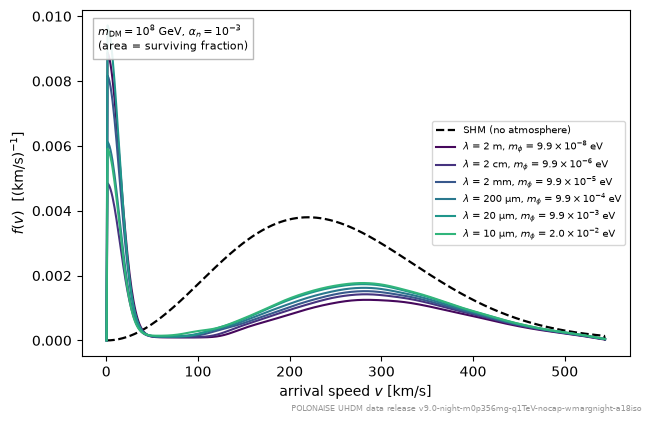

In [3]:
ALPHA_N_SHOW = 1e-3   # showcase coupling the release curves were built at
M_SHOW = 1e8          # showcase DM mass [GeV]

KMS = units.C_M_S / 1e3   # c -> km/s
v, f_shm = rel.speed_dist("shm")   # SHM at the top of the atmosphere

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(v * KMS, f_shm / KMS, "k--", lw=1.6, label="SHM (no atmosphere)")
print(f"{'range':>10} {'survival fraction':>18}")
for tag, lamb, color in LAMBDAS:
    if tag in HIDE:
        continue
    _, fv = rel.speed_dist(tag)
    ax.plot(v * KMS, fv / KMS, color=color, label=range_legend(lamb))
    print(f"{lamb_label(lamb).split(' = ')[-1]:>10} "
          f"{rel.survival_fraction(tag):>18.3f}")
ax.set_xlabel(r"arrival speed $v$ [km/s]")
ax.set_ylabel(r"$f(v)$  [(km/s)$^{-1}$]")
ax.text(0.03, 0.96,
        rf"$m_{{\rm DM}} = 10^8$ GeV, $\alpha_n = 10^{{-3}}$"
        "\n(area = surviving fraction)",
        transform=ax.transAxes, ha="left", va="top", fontsize=8,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(fontsize=7, loc="center right")
fig.tight_layout()
save_figure(fig, "02_arrival_speed_distributions")

### Spectra

The attenuated **raw** $dR/dq$ — before the per-mode efficiency
$\varepsilon(q)$, so the curves are the same for every mode — for the six ranges
drawn here (2 µm is loaded and
exported but hidden; the eighth showcase family, 20 cm, is not loaded by
this notebook) at a fixed mass and coupling. At
fixed coupling the spectrum weakens and steepens as the range shrinks (the
momentum cap $\tilde q < K_1(\xi)$ bites); the longest ranges sit on the
**massless analytic curve** (black dashed,
$d\sigma/dq = 2\pi\alpha^2/(v^2q^3)$), with the endpoint at the halo
kinematic limit.


<>:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_3863144/262721452.py:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  "\narrival $f(v)$ computed once, at $\lambda$ = 200 µm",


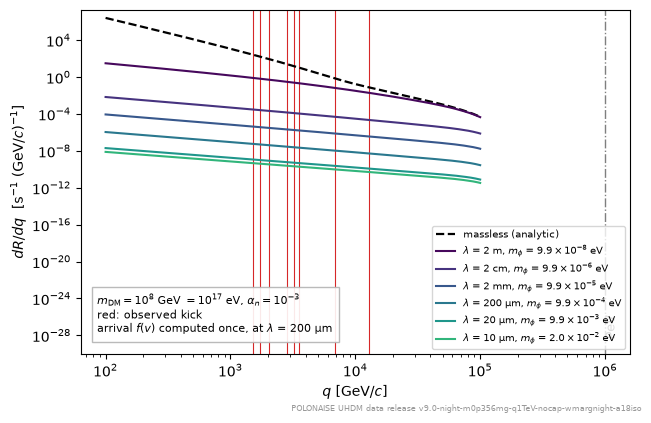

In [4]:
ALPHA_N_SHOW = 1e-3   # showcase coupling
M_SHOW = 1e8          # showcase DM mass [GeV]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
# observed kicks first (thin, behind) so the spectra curves read on top of them
for q_ev in EVENTS:
    ax.axvline(q_ev, color="#d62728", lw=0.8, zorder=0)
q, r_massless = rel.raw_spectrum("massless")
ax.loglog(q, r_massless, color="k", ls="--", lw=1.6, label="massless (analytic)")
for tag, lamb, color in LAMBDAS:
    if tag in HIDE:
        continue
    q, r = rel.raw_spectrum(tag)
    ax.loglog(q, r, color=color, label=range_legend(lamb))
ax.set_ylim(bottom=1e-30)
ax.set_xlabel(r"$q$ [GeV/$c$]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ (GeV/$c$)$^{-1}$]")
ax.axvline(1e6, color="#7f7f7f", lw=1.0, ls="-.")
ax.text(1e6, 0.03, " PeV", color="#555555", fontsize=9, ha="left",
        va="bottom", rotation=90, transform=ax.get_xaxis_transform())
ax.text(0.03, 0.05,
        rf"$m_{{\rm DM}} = 10^8$ GeV $= 10^{{17}}$ eV, $\alpha_n = 10^{{-3}}$"
        "\nred: observed kick"
        "\narrival $f(v)$ computed once, at $\lambda$ = 200 µm",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(fontsize=7)
fig.tight_layout()
save_figure(fig, "02_spectra")

## Statistics: what the extremeness means

At each grid point the extremeness is

$$p = \Pr\big(C_\text{max}^\text{pseudo} < C_\text{max}^\text{obs}\,\big|\,m_\text{DM}, \alpha_n,\ \text{no background}\big),$$

the fraction of background-free pseudo-experiments generated *under that
hypothesis* whose most-anomalously-empty spectral stretch looks **less** empty
than the data. Physically: $p = 0.95$ means the hypothesis predicts enough
events that 95% of the time our gaps would have been filled in more than they
are: the observed emptiness sits in the 5% tail, so the point is excluded at
95% CL. The surface *is* the confidence level: the rule "exclude where
$p \ge C$" wrongly rejects a true hypothesis at most $(1-C)$ of the time
(frequentist coverage, not a posterior probability), and any CL is a level set
of the same array; the 90% contour needs no rescan. The test is one-sided by
construction: background can only *add* events, filling gaps and lowering $p$,
so backgrounds can weaken an exclusion but never fake one. This full extremeness
surface ships assembled in the data release, so every confidence level here is
just a level set read straight from it.

## Scan mechanics

Each scan is a parallel sweep over grid points; at each point: attenuation
ODE → $dR/dq$ → expected count
$\mu$ and normalized spectrum shape → optimum-interval extremeness of the
observed events. Because the spectrum shape depends on the coupling being
limited (finite range, attenuation), the limit is a **level set of the
extremeness surface**, not a single $\mu$ solve. Monte-Carlo calibration
tables are shared across the plane by rounding $\mu$ onto a 2%-spaced log
grid. Runtime knobs: `n_grid`/`n_ode` (attenuation ODE resolution, the
dominant cost), `n_mc` (calibration statistics), and the grid densities; see
`FID` in the scripts. These scans ship pre-assembled in the data release
(the current release cube — see the version tag in the file /
`release/README.md`), so the notebooks read the finished cube
rather than recomputing it.

## Appendix: validation checks

1. **$K_1$ → Coulomb convergence.** At $\lambda$ = 2 m and small coupling
   (threshold kicks come from close flybys, $b \ll \lambda$, the Coulomb
   regime), the tabulated $K_1$ machinery must reproduce the closed form
   $c\,\alpha^2/(v^2 q^3)$, whose coefficient is set by the cube's projection
   kernel — $8\pi/3$ for the isotropic-folded convention this release ships,
   $2\pi$ for the historical planar-signed one. Both sides of the check are
   built under whichever kernel the open file names, so the ratios below should
   be $\approx 1$ either way.
2. **Log-space vs direct.** Of the ranges loaded here only $\lambda$ = 2 µm
   reaches the log-space branch ($\xi = R_\text{eff}/\lambda = 130$, past the
   $\xi > 30$ switch); 10 µm is already direct at $\xi = 26$, and the released
   $\lambda$ axis — 20 µm, 200 µm, 2 mm, the 200 m convergence slice and the
   massless sentinel — tops out at $\xi = 13$, so the scanned cube is entirely
   direct. `tests/test_cross_section_ln.py` pins agreement between the two
   paths at the percent level wherever both are healthy
   ($\xi \le 10$ across the tabulated range), and finiteness at $\xi = 1000$
   where the direct $K_1$ underflows. Run `pytest` to reproduce.
3. **Spot checks along the reference contour.** The reach $b_\text{max}$, the
   transit count $N_t$, and $\mu$ at ten points on the 95% boundary, read
   cell-by-cell from the release. Here $b_\text{max}$ is the
   **flux-averaged reach** $\sqrt{\langle b^2\rangle}$ read from the halo cube,
   systematically smaller than a max-over-$v$ impact parameter would be; the
   physical claim is the same either way, since the reach stays far below the
   apparatus scale,
   so the point-sensor impulse model is safe on the boundary. Expect
   $N_t \ge \mu \gtrsim 3$ everywhere (exclusion is never claimed where no
   particle is expected to pass within reach).

The spot checks below read the 200 µm extremeness plane straight from the data
release and trace its 95% contour:

In [5]:
# validate: K1 machinery at lambda = 2 m vs the analytic Coulomb projection.
# Coulomb regime requires b << lambda, i.e. q_tilde >> 1: pick a small coupling
# so threshold kicks come from close flybys.
import os
os.environ["TQDM_DISABLE"] = "1"
from luhdm import cross_section, rate

# Both sides are built under the CUBE's projection kernel, read off the file:
# the two kernels differ by a fixed factor in the Coulomb limit, so comparing a
# handle built one way against a closed form written the other way would pass
# or fail for the wrong reason. rel.make_xsec threads the file's convention.
XS_2M = rel.make_xsec(2.0)   # 2 m mediator handle, built here for this check
alpha_chk = 1e-6 * config.N_NEUTRONS
v_chk = 1e-3
qs_chk = np.geomspace(Q_THRESH, 10 * Q_THRESH, 6)
num = rate.dsigma_dq_any(qs_chk, alpha_chk, v_chk, XS_2M)
ana = cross_section.cross_section_rutherford_projection_capped(
    qs_chk, alpha_chk, v_chk, None, kernel=rel.projection_kernel)
print(f"projection kernel: {rel.projection_kernel}")
print("K1 machinery / analytic (should be ~1):", np.round(num / ana, 4))

projection kernel: isotropic-folded
K1 machinery / analytic (should be ~1): [1.0083 1.0149 1.0186 1.0178 1.0136 1.0054]


In [6]:
# 95% contour of the reference-range (200 µm) extremeness plane, read straight
# from the release; sample ~10 boundary points and dump each cell.
REF_TAG = "200um"
ext_ref = rel.mass_plane("extremeness", mode=MODE_NUMBER, lam=REF_TAG,
                         f_dm=F_DM)
ms_ref = rel.axes.mass_gev
alphas_ref = rel.axes.alpha_n

_f, _a = plt.subplots()
cs95_ref = _a.contour(ms_ref, alphas_ref, ext_ref, levels=[CONFIDENCE])
plt.close(_f)

def contour_polyline(cs):
    parts = []
    for seg in cs.allsegs[0]:
        parts.append(seg)
        parts.append(np.full((1, 2), np.nan))
    return np.vstack(parts) if parts else np.empty((0, 2))

poly = contour_polyline(cs95_ref)
pts = poly[~np.isnan(poly).any(axis=1)]

# b_max is now the flux-averaged reach sqrt(<b^2>) taken from the halo cube
# (systematically smaller than the old max-over-v impact parameter); the
# physical claim -- reach far below the apparatus scale -- is unchanged.
print(f"{'m [GeV]':>10} {'alpha_n':>9} {'b_max flux-avg [cm]':>20} "
      f"{'N_transit':>10} {'mu':>7}")
if len(pts) == 0:
    print("(no 95% contour on this plane)")
else:
    idx = np.linspace(0, len(pts) - 1, 10).astype(int)
    for m, a in pts[idx]:
        c = rel.cell(m, a, REF_TAG, mode=MODE_NUMBER, f_dm=F_DM)
        print(f"{c['mass_gev']:>10.2e} {c['alpha_n']:>9.1e} "
              f"{c['bmax'] * 100:>20.2e} {c['n_transit']:>10.1f} {c['mu']:>7.2f}")
    print("\nN_transit >= mu everywhere: exclusion is never claimed where fewer "
          "than ~3 particles are expected within reach.")

   m [GeV]   alpha_n  b_max flux-avg [cm]  N_transit      mu
  2.71e+06   8.0e-09             1.05e-02     1464.4   10.36
  1.27e+08   2.4e-08             3.87e-02      225.1   30.69
  1.98e+09   2.2e-07             7.70e-02       52.2   24.40
  1.79e+10   1.7e-05             1.55e-01       24.5   17.52
  9.31e+10   4.2e-03             2.59e-01       12.8   10.30
  3.44e+09   1.2e-02             2.82e-01       58.7   40.59
  1.27e+08   4.2e-03             2.59e-01      106.6   37.43
  2.71e+06   4.6e-04             2.20e-01    10869.6 1455.88
  9.02e+05   1.9e-06             1.03e-01    74985.4 1396.00
  2.71e+06   8.0e-09             1.05e-02     1464.4   10.36

N_transit >= mu everywhere: exclusion is never claimed where fewer than ~3 particles are expected within reach.
